In [1]:
import tensorflow as tf
print("tf version:", tf.__version__)

tf version: 2.21.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

import nltk
from wordcloud import WordCloud

In [3]:
import tensorflow as tf

In [4]:
df = pd.read_csv("data/Hotel_Reviews.csv", nrows=1000)
df.shape

(1000, 2)

In [5]:
df.columns

Index(['Review', 'Rating'], dtype='object')

In [6]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [7]:
import pandas as pd

df = pd.read_csv("data/Hotel_Reviews.csv", nrows=1000)
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [8]:
df["clean_review"] = df["Review"].str.lower()
df[["Review", "clean_review"]].head()

,Review,clean_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms not 4* experience hotel monaco seat...
3,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso..."


In [9]:
import re

def basic_clean(text):
    text = re.sub(r"[^a-z\s]", " ", text)   # keep only letters a–z and spaces
    text = re.sub(r"\s+", " ", text)        # collapse multiple spaces
    return text.strip()

df["clean_review"] = df["clean_review"].apply(basic_clean)
df[["Review", "clean_review"]].head()

,Review,clean_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms not experience hotel monaco seattle...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [10]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Mazum
[nltk_data]     Paudel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return " ".join(filtered)

df["clean_review"] = df["clean_review"].apply(remove_stopwords)
df[["Review", "clean_review"]].head()

,Review,clean_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms experience hotel monaco seattle goo...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [12]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")  # optional but helps

[nltk_data] Downloading package wordnet to C:\Users\Mazum
[nltk_data]     Paudel\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Mazum
[nltk_data]     Paudel\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [13]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmas = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(lemmas)

df["clean_review"] = df["clean_review"].apply(lemmatize_text)
df[["Review", "clean_review"]].head()

,Review,clean_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [14]:
df[["clean_review"]].iloc[2]["clean_review"]

'nice room experience hotel monaco seattle good hotel n level positive large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized missed separate wakeup call concierge busy hard touch n provide guidance special request tv hard use ipod sound dock suite non functioning decided book mediterranean suite night weekend stay st choice rest party filled comparison w spent night larger square footage room great soaking tub whirlpool jet nice shower stay hotel arrange car service price tip reasonable driver waiting arrival checkin easy downside room picked person jacuzi tub bath accessory salt bubble bath n stay night got checked voucher bottle champagne nice gesture fish waiting room impression room huge open space felt room big tv far away bed chore change channel ipod dock broken disappointing morning way asked desk check thermostat said f degree warm try cover face night bright blue light kept got room night s

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

# limit vocab size to something like 5000 most frequent words
vocab_size = 5000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_review"])   # build word index

sequences = tokenizer.texts_to_sequences(df["clean_review"])
len(sequences), sequences[0][:20]

(1000,
 [10,
  2,
  205,
  30,
  36,
  11,
  158,
  5,
  2,
  956,
  114,
  214,
  135,
  122,
  1004,
  415,
  61,
  139,
  30,
  44])

In [16]:
word_index = tokenizer.word_index
len(word_index)

7700

In [17]:
for word, idx in list(word_index.items())[:20]:
    print(idx, "->", word)

1 -> <OOV>
2 -> hotel
3 -> room
4 -> great
5 -> stay
6 -> n
7 -> staff
8 -> night
9 -> location
10 -> nice
11 -> good
12 -> place
13 -> bed
14 -> service
15 -> stayed
16 -> time
17 -> day
18 -> seattle
19 -> like
20 -> clean


In [18]:
sequence_lengths = [len(seq) for seq in sequences]
min_len = min(sequence_lengths)
max_len = max(sequence_lengths)
avg_len = sum(sequence_lengths) / len(sequence_lengths)
min_len, max_len, avg_len

(8, 641, 80.04)

In [19]:
import numpy as np

max_length = int(np.percentile(sequence_lengths, 90))
max_length

148

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 148  # from your percentile
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",    # pad at the end
    truncating="post"  # cut off extra tokens at the end
)

padded_sequences.shape, padded_sequences[0][:50]

((1000, 148),
 array([  10,    2,  205,   30,   36,   11,  158,    5,    2,  956,  114,
         214,  135,  122, 1004,  415,   61,  139,   30,   44,  278,  120,
          33,  289,  314, 2141,   41,    3,    3,   20,   10,  154,   13,
          31, 1147, 2142, 4110,  159,  169, 2143,   19,  344,  533,    3,
           8,   52,  353, 3034,   48,  864], dtype=int32))

In [21]:
# keep only ratings 1,2,4,5
mask = df["Rating"].isin([1, 2, 4, 5])
df_binary = df[mask].copy()

def rating_to_label(r):
    if r >= 4:
        return 1  # positive
    else:
        return 0  # negative

df_binary["label"] = df_binary["Rating"].apply(rating_to_label)

df_binary[["Review", "Rating", "label"]].head()
df_binary["label"].value_counts()

label
1    645
0    218
Name: count, dtype: int64

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

texts = df_binary["clean_review"].tolist()
labels = df_binary["label"].values   # numpy array of 0/1

vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

sequence_lengths = [len(seq) for seq in sequences]
max_length = int(np.percentile(sequence_lengths, 90))

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

padded_sequences.shape, max_length, len(labels)

((863, 148), 148, 863)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((690, 148), (173, 148), (690,), (173,))

In [24]:
vocab_size = 5000  # same as you used for the Tokenizer
max_length = padded_sequences.shape[1]  # should be 148

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

embedding_dim = 64

model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dense(1, activation="sigmoid"))

model_rnn.summary()

C:\Users\Mazum Paudel\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Texts and labels from df_binary
texts = df_binary["clean_review"].tolist()
labels = df_binary["label"].values

# Tokenizer setup
vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

# Percentile-based max_length
sequence_lengths = [len(seq) for seq in sequences]
max_length = int(np.percentile(sequence_lengths, 90))

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

padded_sequences.shape, max_length

((863, 148), 148)

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Texts and labels from df_binary
texts = df_binary["clean_review"].tolist()
labels = df_binary["label"].values

# Tokenizer setup
vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

# Percentile-based max_length
sequence_lengths = [len(seq) for seq in sequences]
max_length = int(np.percentile(sequence_lengths, 90))

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

padded_sequences.shape, max_length

((863, 148), 148)

In [28]:
vocab_size = 5000      # same value you used when creating the Tokenizer earlier
max_length = X_train.shape[1]   # should be 148

vocab_size, max_length

(5000, 148)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

embedding_dim = 64

model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dense(1, activation="sigmoid"))

model_rnn.summary()

C:\Users\Mazum Paudel\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_rnn.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7500 - loss: 0.5746 - val_accuracy: 0.7319 - val_loss: 0.5784
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7663 - loss: 0.5433 - val_accuracy: 0.7319 - val_loss: 0.5675
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7971 - loss: 0.4953 - val_accuracy: 0.7246 - val_loss: 0.5838
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8043 - loss: 0.4700 - val_accuracy: 0.7536 - val_loss: 0.5680


In [32]:
test_loss, test_acc = model_rnn.evaluate(X_test, y_test, verbose=0)
test_loss, test_acc

(0.5686053037643433, 0.7456647157669067)

In [33]:
history_rnn.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

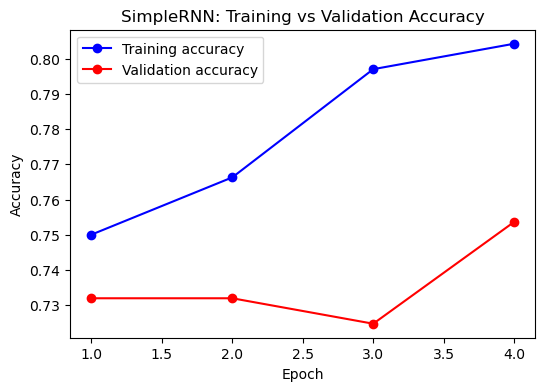

In [34]:
import matplotlib.pyplot as plt

acc = history_rnn.history["accuracy"]
val_acc = history_rnn.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SimpleRNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

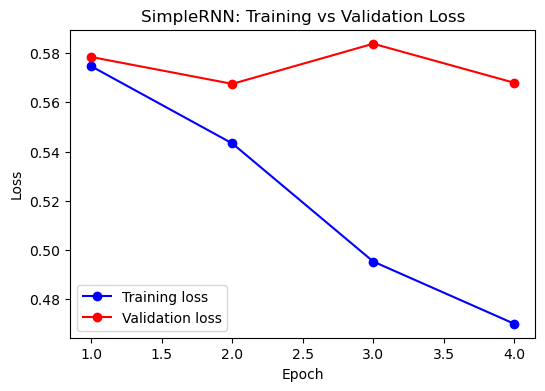

In [35]:
loss = history_rnn.history["loss"]
val_loss = history_rnn.history["val_loss"]
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimpleRNN: Training vs Validation Loss")
plt.legend()
plt.show()

In [36]:
maxlen = 148

In [37]:
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

In [38]:
lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=7,       # match your SimpleRNN epochs
    batch_size=32,  # or whatever you used
    validation_split=0.2
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
whos

Variable               Type                    Data/Info
--------------------------------------------------------
Dense                  type                    <class 'keras.src.layers.core.dense.Dense'>
EarlyStopping          type                    <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
Embedding              type                    <class 'keras.src.layers.<...>ore.embedding.Embedding'>
LSTM                   type                    <class 'keras.src.layers.rnn.lstm.LSTM'>
Sequential             type                    <class 'keras.src.models.sequential.Sequential'>
SimpleRNN              type                    <class 'keras.src.layers.<...>nn.simple_rnn.SimpleRNN'>
Tokenizer              type                    <class 'keras.src.legacy.<...>ocessing.text.Tokenizer'>
WordCloud              type                    <class 'wordcloud.wordcloud.WordCloud'>
WordNetLemmatizer      type                    <class 'nltk.stem.wordnet.WordNetLemmatizer'>
X_test             

In [43]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=7,       # match your SimpleRNN epochs
    batch_size=32,  # or whatever you used
    validation_split=0.2
)

Epoch 1/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7536 - loss: 0.5731 - val_accuracy: 0.7319 - val_loss: 0.5875
Epoch 2/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7518 - loss: 0.5541 - val_accuracy: 0.7319 - val_loss: 0.5715
Epoch 3/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7518 - loss: 0.5516 - val_accuracy: 0.7319 - val_loss: 0.5712
Epoch 4/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7736 - loss: 0.5486 - val_accuracy: 0.7319 - val_loss: 0.5679
Epoch 5/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7899 - loss: 0.5355 - val_accuracy: 0.7681 - val_loss: 0.5599
Epoch 6/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7627 - loss: 0.5033 - val_accuracy: 0.7319 - val_loss: 0.5102
Epoch 7/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7536 - loss: 0.4986 - val_accuracy: 0.7319 - val_loss: 0.5456


In [44]:
test_loss_lstm, test_acc_lstm = lstm_model.evaluate(X_test, y_test)
test_loss_lstm, test_acc_lstm

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7457 - loss: 0.5501


(0.5501374006271362, 0.7456647157669067)

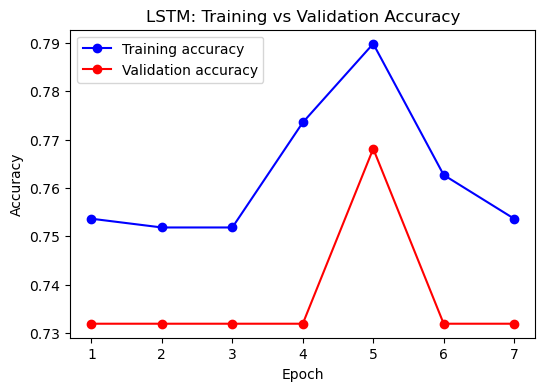

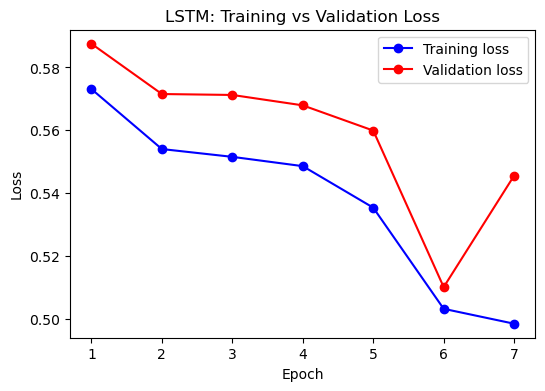

In [45]:
# Accuracy
acc_lstm = history_lstm.history["accuracy"]
val_acc_lstm = history_lstm.history["val_accuracy"]
epochs = range(1, len(acc_lstm) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, acc_lstm, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc_lstm, "ro-", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM: Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss
loss_lstm = history_lstm.history["loss"]
val_loss_lstm = history_lstm.history["val_loss"]

plt.figure(figsize=(6, 4))
plt.plot(epochs, loss_lstm, "bo-", label="Training loss")
plt.plot(epochs, val_loss_lstm, "ro-", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM: Training vs Validation Loss")
plt.legend()
plt.show()